# The Milne problem solved by ISIF

Python/Jupyter translation of `FFmilne.edp` (FreeFem++). See `FFmilne.md` for details.

The Milne problem of interest to us is

$$
\mu\partial_x I+ I = \frac12\int_{-1}^1 I\, d\mu~~x\in(0,1),\qquad
I(0,\mu)|_{\mu>0}=0,~~I(1,\mu)|_{\mu<0} = c_s\delta(\mu-\mu_s).
$$

It is an equation for the radiance $I$ versus altitude $x$ and ray direction cosine $\mu$.
The radiation source is a collimated sunlight in direction $\mu_s$ of intensity $c_s$.
Denote the directional averaged radiance

$$
J_0(x) = \frac12\int_{-1}^1 I \,d\mu.
$$

By the method of characteristics one shows that it is the solution of the integral equation

$$
J_0(x) = \frac12\int_0^1 E_1(|x-x'|)\,J_0(x')\,dx' + \frac{c_s}2 e^{-\frac{x}{\mu_s}},
$$

where $E_1$ is the exponential integral (`scipy.special.exp1`, `gslsfexpintE1` in FreeFem).
It is solved by the fixed-point iteration ISIF (Integral Source Iteration Formulation).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import exp1

Matplotlib is building the font cache; this may take a moment.


## Discretization

As in the FreeFem++ script, $J_0$ is continuous piecewise linear ($P^1$) on a uniform
mesh of $(0,1)$ with 80 segments. The integrals `int1d(Th)(...)` are computed with a
3-point Gauss quadrature on each element; the quadrature points never coincide with the
evaluation nodes, so the logarithmic singularity of $E_1$ at 0 is handled harmlessly,
exactly as in FreeFem++.

In [3]:
N = 50                                  # number of segments of the altitude grid
xn = np.linspace(0.0, 1.0, N + 1)       # mesh nodes on (0,1)
h = xn[1] - xn[0]

# 3-point Gauss quadrature points/weights on every element
g, gw = np.polynomial.legendre.leggauss(3)                 # reference points on (-1,1)
xq = (xn[:-1, None] + h * (g[None, :] + 1) / 2).ravel()    # all quadrature points
wq = np.tile(h * gw / 2, N)                                # matching weights

def at_quad(v):
    """P1 interpolation of nodal values v at the quadrature points."""
    return np.interp(xq, xn, v)

cs, mus = 1.0, 1.0 / np.sqrt(3.0)       # sunlight intensity and direction cosine

# kernel matrix: K[j, q] = w_q * E1(|xq_q - xn_j|), so that
# (K @ at_quad(J0))[j] = int_0^1 E1(|x - xn_j|) J0(x) dx
K = wq[None, :] * exp1(np.abs(xq[None, :] - xn[:, None]))

## ISIF fixed-point iteration

$J_0^{n+1}(x) = \frac12\int_0^1 E_1(|x-x'|)J_0^n(x')dx' + \frac{c_s}2 e^{-x/\mu_s}$,
starting from $J_0^0=0$. The value $J_0(0)$ is printed to check convergence.

In [4]:
J0 = np.zeros(N + 1)
print("Convergence of J0(0)")
for i in range(15):                     # ISIF
    J0 = 0.5 * (K @ at_quad(J0)) + 0.5 * cs * np.exp(-xn / mus)
    print(J0[0])                        # to check convergence

Convergence of J0(0)
0.5
0.6418727055040262
0.7102493435742998
0.7483555097163067
0.7708276525305279
0.7844119411638165
0.7927176265886421
0.7978233590153463
0.8009701748717428
0.8029121166616205
0.8041112628233704
0.8048519619492561
0.8053095532803324
0.8055922668193798
0.8057669422201988


In [5]:
def J0eval(tau):
    """Evaluate the P1 function J0 at tau, like J0(tau) in FreeFem++."""
    return np.interp(tau, xn, J0)

print(" tau    J0(tau)")
for tau in np.arange(0, 1, 0.03):
    print(f"{tau:5.2f}  {J0eval(tau):.6f}")

 tau    J0(tau)
 0.00  0.805767
 0.03  0.822485
 0.06  0.824956
 0.09  0.820959
 0.12  0.813909
 0.15  0.804204
 0.18  0.792942
 0.21  0.780184
 0.24  0.766489
 0.27  0.751855
 0.30  0.736617
 0.33  0.720759
 0.36  0.704496
 0.39  0.687812
 0.42  0.670848
 0.45  0.653591
 0.48  0.636135
 0.51  0.618467
 0.54  0.600651
 0.57  0.582671
 0.60  0.564571
 0.63  0.546327
 0.66  0.527970
 0.69  0.509465
 0.72  0.490832
 0.75  0.472017
 0.78  0.453029
 0.81  0.433779
 0.84  0.414262
 0.87  0.394306
 0.90  0.373870
 0.93  0.352543
 0.96  0.330050
 0.99  0.303732


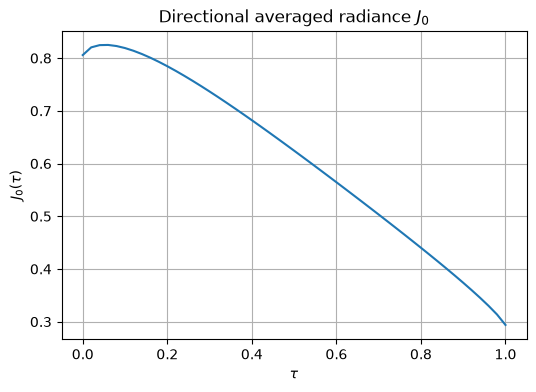

In [6]:
plt.figure(figsize=(6, 4))
plt.plot(xn, J0)
plt.xlabel(r"$\tau$")
plt.ylabel(r"$J_0(\tau)$")
plt.title("Directional averaged radiance $J_0$")
plt.grid(True)
plt.show()

## Recovering $I(x,\mu)$ from $J_0$

To compute $I(x,\mu)$ one must approximate the Dirac mass at $\mu_s$ by an exponential
and use the following when $\mu>0$:

$$
I(x,\mu)\approx \int_0^x \frac1\mu e^{-\frac {|x-x'|}\mu}J_0(x')\,dx'
 + c_s\, e^{-\frac x{\mu_s}}\, \frac{e^{-\lambda(\mu-\mu_s)^2}}{\int_0^1 e^{-\lambda(\mu'-\mu_s)^2}d\mu'}.
$$

When $\mu<0$,

$$
I(x,\mu)= -\int_x^1 \frac1\mu e^{\frac {x-x'}\mu}J_0(x')\,dx'.
$$

Note: most of the radiance is in the collimated term
$C e^{-\lambda(\mu-\mu_s)^2} e^{-x/\mu_s}$; set `C = 0` below to see the rest of the signal.

In [7]:
def convolp(xx, mu):
    """int_0^xx exp((x-xx)/mu) J0(x)/mu dx, for mu > 0."""
    return np.sum(wq * (xq < xx) * np.exp((xq - xx) / mu) * at_quad(J0) / mu)

def convoln(xx, mu):
    """-int_xx^1 exp((x-xx)/mu) J0(x)/mu dx, for mu < 0."""
    return -np.sum(wq * (xq > xx) * np.exp((xq - xx) / mu) * at_quad(J0) / mu)

# normalization of the regularized Dirac mass at mu_s
lam, dmu = 500.0, 0.01
C = cs / np.sum(np.exp(-lam * (np.arange(0, 1, dmu) - mus) ** 2) * dmu)
# C = 0   # uncomment to hide the collimated sunlight and see the rest of the signal

In [8]:
mup = np.arange(0.03, 1.0, 0.03)        # mu > 0
mun = np.arange(-1.0, -0.03, 0.03)      # mu < 0
xx = np.arange(0.0, 1.0, 0.03)

Ip = np.array([[convolp(x_, mu) + C * np.exp(-lam * (mu - mus) ** 2) * np.exp(-x_ / mus)
                for x_ in xx] for mu in mup])
In = np.array([[convoln(x_, mu) for x_ in xx] for mu in mun])

# assemble the surface mu, x -> I(x, mu)
MU = np.concatenate([mun, mup])
I = np.vstack([In, Ip])

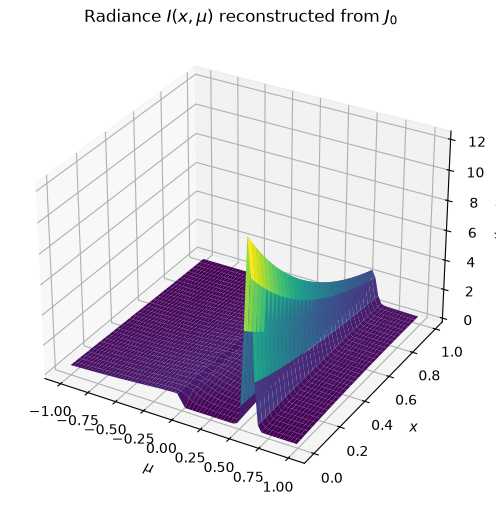

In [9]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

X, M = np.meshgrid(xx, MU)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(M, X, I, cmap="viridis", rstride=1, cstride=1, linewidth=0)
ax.set_xlabel(r"$\mu$")
ax.set_ylabel(r"$x$")
ax.set_zlabel(r"$I(x,\mu)$")
ax.set_title(r"Radiance $I(x,\mu)$ reconstructed from $J_0$")
plt.show()